In [2]:
# --- modules ---
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import glob, os, sys
from pathlib import Path
import rootutils
import geopandas as gpd


# --- hard coded paths ---
ROOT_PATH = rootutils.find_root(search_from=Path.cwd(), indicator=".git")
sys.path.append(str(ROOT_PATH))
ROOTDIR_DATA = os.path.join(ROOT_PATH, "Data")
sys.path.append(ROOTDIR_DATA)

# --- hard coded constants ---
from Scripts.constants import (
    CATCHMENT_AREA_DEMER, #area in km2
    INITIAL_STORAGE_DEMER, #initial storage in m3
)


## code to load the data 

In [ ]:
# --- load the meteorological data ---
df_Meteo_Demer = next((f for f in glob.glob(os.path.join(ROOTDIR_DATA, "processed", "Meteo*Demer*.csv"))), None)
if df_Meteo_Demer is None:
    raise FileNotFoundError("No meteorological data file found for the Demer catchment.")

df_Meteo_Demer = pd.read_csv(df_Meteo_Demer)

# --- load the discharge data ---
df_Discharge_Demer = next((f for f in glob.glob(os.path.join(ROOTDIR_DATA, "processed", "Afvoer*Demer*.csv"))), None)
if df_Discharge_Demer is None:
    raise FileNotFoundError("No discharge data file found for the Demer catchment.")

df_Discharge_Demer = pd.read_csv(df_Discharge_Demer)

In [13]:
# --- put the dates properly ---
# meteo data
df_Meteo_Demer['Datum'] = pd.to_datetime(df_Meteo_Demer['Datum'], 
                                         format='%Y-%m-%d'
                                         )

# discharge data
df_Discharge_Demer["Datum_tijd"] = pd.to_datetime(df_Discharge_Demer["Datum_tijd"],
                format='%Y-%m-%d %H:%M:%S'
                )
df_Discharge_Demer=df_Discharge_Demer.rename(columns={"Datum_tijd": "Datum"})

## Question 2: Compute Monthly Storage using a mass balance approach

In [15]:
# --- calculate monthly mean P and ET data ---
# convert P and ET data to m3
df_Meteo_Demer["P (m3)"]=df_Meteo_Demer["P (mm)"]*CATCHMENT_AREA_DEMER*1e3 #convert mm to m3
df_Meteo_Demer["ET (m3)"]=df_Meteo_Demer["ET (mm)"]*CATCHMENT_AREA_DEMER*1e3 #convert mm to m3

# get the monthly mean values
df_Meteo_Demer_MM = df_Meteo_Demer.groupby([
                                        df_Meteo_Demer["Datum"].dt.year.rename("Year"),
                                        df_Meteo_Demer["Datum"].dt.month.rename("Month")
                                        ]
                                        )[["P (m3)", "ET (m3)"]].sum().reset_index()

#---Calculate the monthly discharge data---
# convert Q data to m3/h
df_Discharge_Demer["Q (m3/h)"] = df_Discharge_Demer["Q (m3/s)"] * 3600

#calculate the monthly discharge
df_Discharge_Demer_MM = df_Discharge_Demer.groupby([
                                        df_Discharge_Demer["Datum"].dt.year.rename("Year"),
                                        df_Discharge_Demer["Datum"].dt.month.rename("Month")
                                        ]
                                        )[["Q (m3/h)"]].sum().reset_index()


# --- merge the meteo and discharge data ---
df_MM = pd.merge(df_Meteo_Demer_MM, df_Discharge_Demer_MM, on=["Year", "Month"], how="inner")

## Question 3: Plot S and delta S in time

In [16]:
# --- calculate the monthly storage change and storage---
# Calculate the monthly change in storage
df_MM["delta_S"] = df_MM["P (m3)"] - df_MM["ET (m3)"] - df_MM["Q (m3/h)"]

# Compute cumulative storage, starting from initial_storage
S = df_MM["delta_S"]
S.iloc[0] = df_MM["delta_S"].iloc[0] + INITIAL_STORAGE_DEMER
df_MM["S"]=S.cumsum()


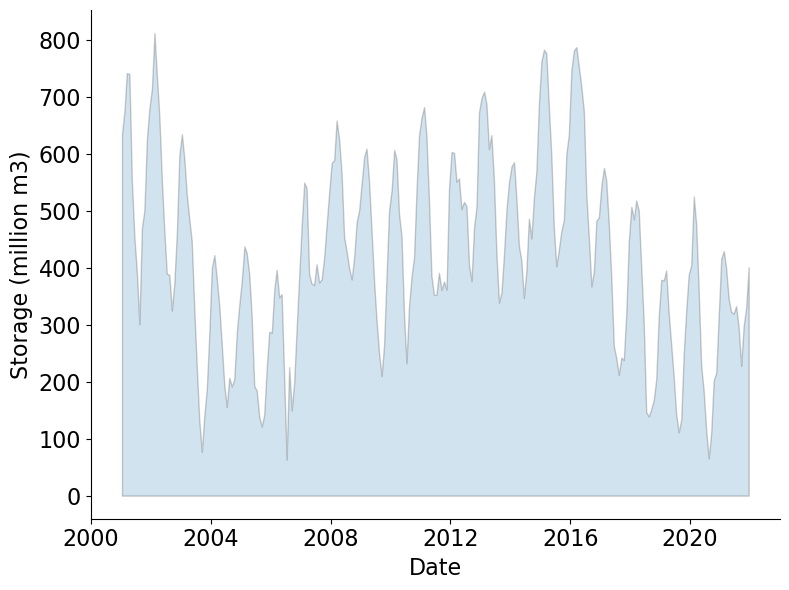

In [17]:
# --- make a function to plot the storage ---
def PlotStorage(
        df_MM: pd.DataFrame,
        date_ini:pd.Timestamp = pd.Timestamp("2000-01-01"),
        date_end:pd.Timestamp = pd.Timestamp("2025-12-31")
    ) -> plt.figure:
    """Figure to plot the monthly mean storage in the Demer catchment."""
    df_plot = df_MM[((df_MM["Year"] >= date_ini.year) & (df_MM["Month"] >= date_ini.month)) & 
                    ((df_MM["Year"] <= date_end.year) & (df_MM["Month"] <= date_end.month))].copy()

    #HACK: add 14 days to the date to get the middle of the month -> give this to the students
    df_plot["plot_date"] =(
        pd.to_datetime(df_plot[["Year","Month"]].assign(day=1))
        + pd.offsets.Day(14)
    )

    # make the figure
    fig,ax=plt.subplots(figsize=(8,6))
    ax.fill_between(df_plot["plot_date"], 
            df_plot["S"]/1e6,
            0, 
            label="Storage (million m3)",
            edgecolor="black",
            alpha=0.2)
    ax.set_xlabel("Date", fontsize=16)
    ax.set_ylabel("Storage (million m3)", fontsize=16)
    ax.tick_params(axis="both", labelsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()
    plt.show()

# --- plot the storage ---
PlotStorage(df_MM)

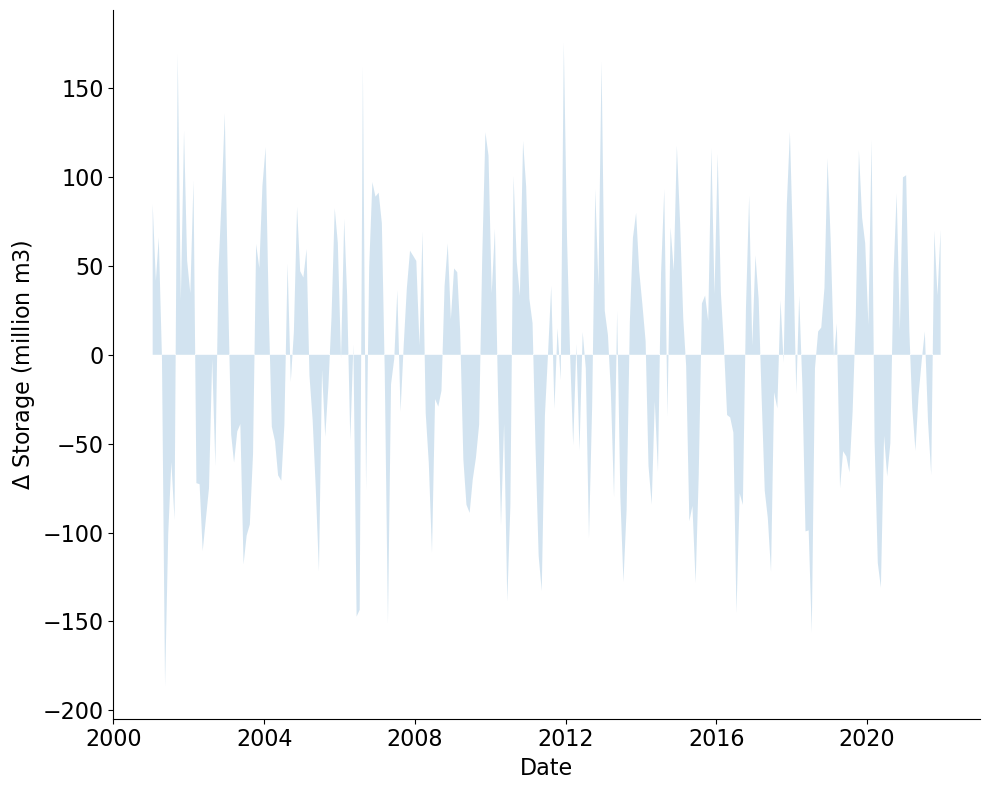

In [18]:
# --- make a function to plot the storage ---

def PlotStorage(
    df_MM: pd.DataFrame,
    date_ini: pd.Timestamp = pd.Timestamp("2000-01-01"),
    date_end: pd.Timestamp = pd.Timestamp("2025-12-31")
    ) -> plt.figure:
    """Function to plot the storage over time."""
    df_plot = df_MM[((df_MM["Year"] >= date_ini.year) & (df_MM["Month"] >= date_ini.month)) & 
                    ((df_MM["Year"] <= date_end.year) & (df_MM["Month"] <= date_end.month))].copy()

    #HACK: add 14 days to the date to get the middle of the month -> give this to the students
    df_plot["plot_date"] =(
        pd.to_datetime(df_plot[["Year","Month"]].assign(day=1))
        + pd.offsets.Day(14)
    )

    fig,ax=plt.subplots(figsize=(10,8))
    ax.fill_between(df_plot["plot_date"], #HACK: use fill_between
            df_plot["delta_S"]/1e6,
            0, 
            label="Storage (million m3)",
            alpha=0.2)
    ax.set_xlabel("Date", fontsize=16)
    ax.set_ylabel(r"$\Delta$ Storage (million m3)", fontsize=16)
    ax.tick_params(axis="both", labelsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()
    plt.show()

# --- plot the storage ---
PlotStorage(df_MM)

# Question 4: compute return periods for peak intensities

In [20]:
def ComputeReturnPeriod(
    df_RP:pd.DataFrame,
    EV_column:str = "P (mm)",
    Date_column:str = "Datum",
    th:float = 10.0 #threshold in mm
    ) -> int:
    """Function to compute the return period of a given event."""
    # --- error handling ---
    # check if columns exist
    if not all (col in df_RP.columns for col in [EV_column, Date_column]):
        raise ValueError(f"Columns {EV_column} and/or "
                            f"{Date_column} not found in dataframe.")

    # make sure the "Datum" column is of datetime type -> give this to the students
    if not pd.api.types.is_datetime64_any_dtype(df_RP["Datum"]):
        df_RP["Datum"] = pd.to_datetime(df_RP["Datum"], format='%d/%m/%Y')

    #---extract data above threshold---
    df_th=df_RP.loc[df_RP[EV_column]>th].copy()
    #check if there is any event, if not, then return NaN
    if df_th.empty:
        return np.nan
    #include first date
    df_th=pd.concat([df_RP.iloc[0:1,], df_th]).reset_index(drop=True)

    #---calculate time difference between events---
    df_th["DeltaDays"] = df_th[Date_column].diff().dt.days #HACK: use diff() to calculate the difference between dates

    #---compute return period---
    RP=df_th.dropna(subset=["DeltaDays"])["DeltaDays"].mean()
    RP=int(np.floor(RP))

    return RP

(0.0, 55.0)

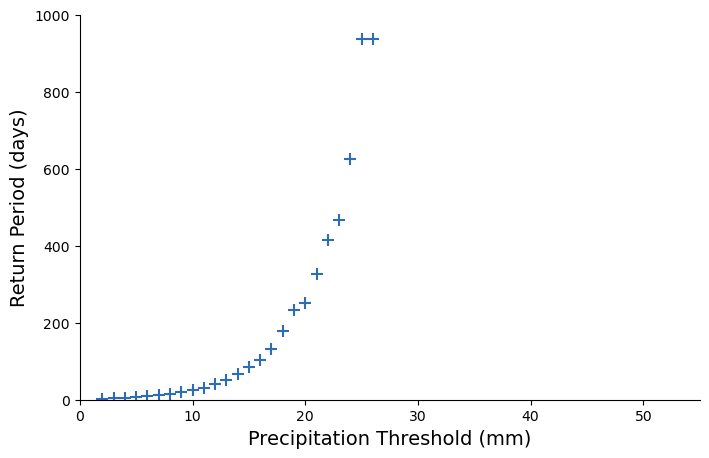

In [21]:
thresholds=np.arange(2,55,1)
returnPeriods=[ComputeReturnPeriod(
                    df_RP = df_Meteo_Demer.copy(),
                    th=th,
                    EV_column="P (mm)",
                    Date_column="Datum"
                    ) for th in thresholds]

fig,ax=plt.subplots(figsize=(8,5))
ax.scatter(thresholds,
           returnPeriods,
           marker="+",
           color="#2C6DB6",
           s=70)
ax.set_ylabel("Return Period (days)", fontsize=14)
ax.set_xlabel("Precipitation Threshold (mm)", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([0, 1000])
ax.set_xlim([0, 55])

## Question 5: compute drought indices 

In [23]:
from scipy.stats import gamma, norm

def computeSPImonth(
        df_MM: pd.DataFrame,
        month: int = 7
    ) -> pd.DataFrame:
    ''' 
    Function to compute the Standardized Precipitation Index (SPI) for a given month.

    First, a gamma distribution is fitted to the precipitation data for the specified month.
    Note that a gamma distribution can only use positive (>0) values, so if there are any zero values in the precipitation data!!

    Next, floc is set to 0 to fix the location parameter of the gamma distribution to start at 0.
    This is important because the gamma distirbution is defined on precipitation, which cannot be < 0!
    If floc is not set to 0, the gamma distribution will be fitted to the data and the location parameter will be
      estimated from the data, which can lead to a negative location parameter and therefore a negative values of the fitted P-distribution, which is not physically possible.
    Note that the fitted gamma distribution = X = loc + Y with Y the gamma distribution and loc the shifting of the distirbution on the x-axis. 
    
    '''

    if not all(c in df_MM.columns for c in ["Month", "P (m3)"]):
        raise ValueError("Columns 'Month' and/or 'P (m3)' must be in the dataframe.")


    data=df_MM.loc[df_MM["Month"]==month, "P (m3)"]
    data=data[data>0] #remove zero values, because the gamma distribution is only defined for positive values!

    if len(data) < 2:
        raise ValueError(f"Not enough data points for month {month} to fit a gamma distribution.")

    # fit the gamma distribution to the data, fixing the location parameter to 0
    shape, loc, scale = gamma.fit(data, floc=0) #note that 0 is returned for loc

    # compute the probability that the July precipitation was <= X -> therefore we use the CDF of the gamma distribution
    p = gamma.cdf(data, shape, loc=loc, scale=scale)

    # convert this probability to the z-score of a normal distribution for the same probability = SPI
    SPI = norm.ppf(p)

    #make a dataframe with the results
    df_SPI=pd.DataFrame({
        "Year": df_MM.loc[df_MM["Month"]==month, "Year"],
        "Month": df_MM.loc[df_MM["Month"]==month, "Month"],
        "SPI": SPI})

    return df_SPI



In [24]:
def plotSPImonth(
        df_MM: pd.DataFrame,
        date_ini: pd.Timestamp = pd.Timestamp("2000-01-01"),
        date_end: pd.Timestamp = pd.Timestamp("2025-12-31")
    ) -> plt.figure:
    """Function to plot the Standardized Precipitation Index (SPI) for a given month."""
    
    #--- compute the SPI for each month ---
    SPI=pd.concat([computeSPImonth(df_MM, month=month) for month in df_MM["Month"].unique()])
    SPI.sort_values(by=["Year", "Month"], inplace=True)
    SPI["plot_date"] = pd.to_datetime(SPI[["Year","Month"]].assign(day=1)) + pd.offsets.Day(14)
  
    # --- filter the data for the specified date range ---
    SPI_filtered = SPI[(SPI["plot_date"] >= date_ini) & 
                       (SPI["plot_date"] <= date_end)]
    
    # --- plot the SPI ---
    fig,ax=plt.subplots(figsize=(20,6))
    ax.plot(SPI_filtered["plot_date"], 
            SPI_filtered["SPI"], 
            color="#2C6DB6", 
            lw=2, alpha=0.5)
    ax.axhline(y=0, color="black", lw=1, ls="--")

    ax.fill_between(SPI_filtered["plot_date"], 
                    -1, SPI_filtered["SPI"], 
                    where=(SPI_filtered["SPI"]<-1) & (SPI_filtered["SPI"]>-1.49), 
                    color="orange", label="drought", lw=2.5)
    ax.fill_between(SPI_filtered["plot_date"], 
                    -1.5, SPI_filtered["SPI"], 
                    where=(SPI_filtered["SPI"]<-1.5) & (SPI_filtered["SPI"]>-1.99), 
                    color="red", label="severe drought",
                    lw=2.5)  
    ax.legend(loc="upper right", fontsize=15) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("Date", fontsize=16)
    ax.set_ylabel("SPI", fontsize=16)
    ax.tick_params(axis="both", labelsize=16)
    fig.tight_layout()
    plt.show()

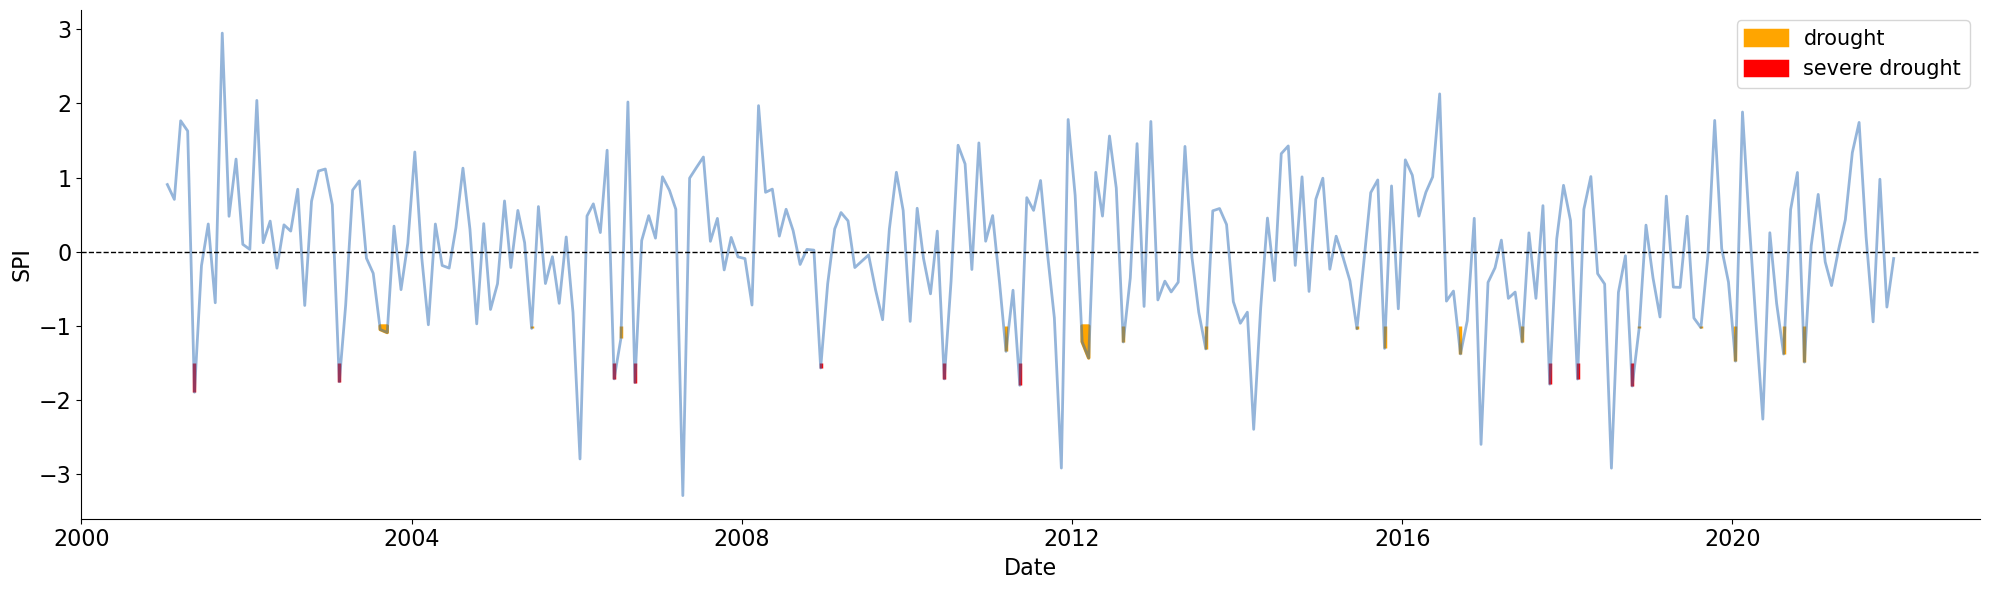

In [25]:
plotSPImonth(df_MM)

# compute the bifurcation number

In [26]:
import geopandas as gpd

def ComputeBifurcationRatio(
    catchment: str = "Zoutleeuw",
    order_column: str = "ORDER"
    ) -> float:
    """Function to compute the bifurcation ratio for a given catchment."""
    
    # --- open the file ---
    file=next((f for f in glob.glob(os.path.join(ROOTDIR_DATA, "QGIS", f"Demer*{stroomgebied}*.shp"))), None)
    if file is None:
        raise FileNotFoundError(f"No shapefile found for the Demer catchment with the name containing '{stroomgebied}'.")

    catchment = gpd.read_file(file)
    
    # --- group by order and count the number of streams ---
    count_orders = catchment.groupby(order_column)[order_column].count().rename("count")
    
    # --- compute the bifurcation ratio ---
    ratio = count_orders / count_orders.shift(-1)
    
    return ratio.mean().item()


stroomgebied="Zoutleeuw"
ComputeBifurcationRatio(
    catchment=stroomgebied,
    order_column="ORDER"
)


4.568410003650968